# Quickstart: Google WeatherNext 2 historical + operational forecasts - dynamical.org Icechunk Zarr

WeatherNext 2 is Google DeepMind's 64-member AI weather ensemble. It produces global 0.25° forecasts four times daily, with 6-hourly lead times from 6 hours through 15 days.

dynamical.org publishes the source archive as two virtual Icechunk products: a fixed historical product for 2022–2024 and an operational product from 2025 onward. They share one analysis-ready schema, so the same xarray code works with both.

WeatherNext 2 data is experimental and is not an official forecast or warning. See the [WeatherNext 2 developer documentation](https://developers.google.com/weathernext/guides/models) and [Google DeepMind overview](https://deepmind.google/science/weathernext/) for model details and limitations.

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install dynamical-catalog

In [2]:
import os

os.environ.setdefault("DYNAMICAL_STAC_CATALOG_URL", "https://stac-staging.dynamical.org/catalog.json")

import dynamical_catalog

HISTORICAL_ID = "google-weathernext2-forecast-historical-virtual"
OPERATIONAL_ID = "google-weathernext2-forecast-operational-virtual"

historical = dynamical_catalog.open(HISTORICAL_ID, chunks=None)
operational = dynamical_catalog.open(OPERATIONAL_ID, chunks=None)
historical

<xarray.DatasetView> Size: 559TB
Dimensions:                             (init_time: 4384, ensemble_member: 64,
                                         lead_time: 60, y: 721, x: 1440)
Coordinates:
  * init_time                           (init_time) datetime64[ns] 35kB 2022-...
    expected_forecast_length            (init_time) timedelta64[us] 35kB ...
  * ensemble_member                     (ensemble_member) int16 128B 0 1 ... 63
  * lead_time                           (lead_time) timedelta64[us] 480B 06:0...
    valid_time                          (init_time, lead_time) datetime64[ns] 2MB ...
  * y                                   (y) float64 6kB -90.0 -89.75 ... 90.0
  * x                                   (x) float64 12kB 0.0 0.25 ... 359.8
    spatial_ref                         int64 8B ...
Data variables:
    pressure_reduced_to_mean_sea_level  (init_time, ensemble_member, lead_time, y, x) float32 70TB ...
    temperature_2m                      (init_time, ensemble_member, lead_time, y, x) float32 70TB ...
    wind_u_100m                         (init_time, ensemble_member, lead_time, y, x) float32 70TB ...
    wind_u_10m                          (init_time, ensemble_member, lead_time, y, x) float32 70TB ...
    total_precipitation_surface         (init_time, ensemble_member, lead_time, y, x) float32 70TB ...
    sea_surface_temperature             (init_time, ensemble_member, lead_time, y, x) float32 70TB ...
    wind_v_100m                         (init_time, ensemble_member, lead_time, y, x) float32 70TB ...
    wind_v_10m                          (init_time, ensemble_member, lead_time, y, x) float32 70TB ...
Attributes:
    dataset_id:           google-weathernext2-forecast-historical-virtual
    dataset_version:      0.1.0
    name:                 Google WeatherNext 2 historical forecast, virtual
    description:          Weather forecasts from the 64-member Google DeepMin...
    attribution:          Google requires this attribution: © 2025 DeepMind T...
    license:              CC-BY-4.0
    spatial_domain:       Global
    spatial_resolution:   0.25 degrees (~20km)
    time_domain:          Forecasts initialized 2022-01-01 00:00:00 UTC to 20...
    time_resolution:      Forecasts initialized every 6 hours
    forecast_domain:      Forecast lead time 6-360 hours (0.25-15 days) ahead
    forecast_resolution:  6 hourly

Both products have dimensions for `init_time`, `ensemble_member`, `lead_time`, `y`, and `x`. The `valid_time` coordinate combines initialization and lead time. WeatherNext 2 retains its native ascending latitude (`y`) and 0–360° longitude (`x`) coordinates.

The operational product is a complete archive, not a low-latency feed: an initialization is published only after it is more than 48 hours old. Variables on atmospheric levels are available from the `pressure_level` group, for example `dynamical_catalog.open(OPERATIONAL_ID, group="pressure_level", chunks=None)`.

In [3]:
print(f"Historical: {historical.init_time.values[0]} to {historical.init_time.values[-1]}")
print(f"Operational: {operational.init_time.values[0]} to {operational.init_time.values[-1]}")

Historical: 2022-01-01T00:00:00.000000000 to 2024-12-31T18:00:00.000000000
Operational: 2025-01-01T00:00:00.000000000 to 2026-08-29T12:00:00.000000000


### Reading the virtual products efficiently

Each source chunk covers the full globe at one lead time. Historical chunks contain four adjacent ensemble members; operational chunks contain one. Cropping is still useful for analysis and plotting, but it does not reduce the source bytes transferred. The examples therefore compare four members at one lead rather than reading long point time series across every lead.

### Historical: Hurricane Beryl track and intensity scenarios

On 4 July 2024, the National Hurricane Center described substantial uncertainty in Beryl's track and intensity over the western Gulf of Mexico. Four days ahead, WeatherNext 2 ensemble members placed different pressure minima along the western Gulf coast. These are equally weighted scenarios, not a confidence interval.

Contemporary context: [NHC Hurricane Beryl discussion 22](https://www.nhc.noaa.gov/archive/2024/al02/al022024.discus.022.shtml).

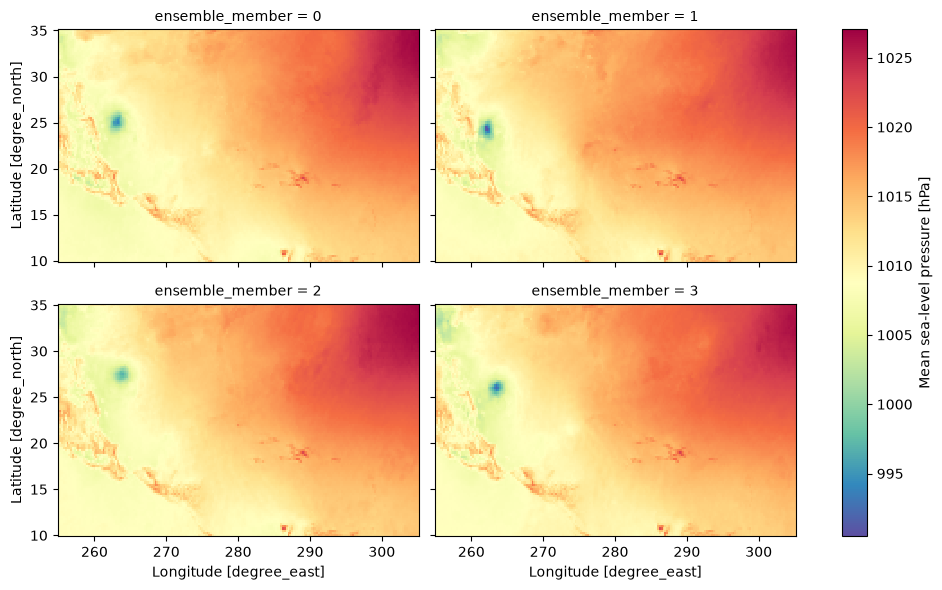

In [4]:
beryl_pressure = (
    historical["pressure_reduced_to_mean_sea_level"]
    .sel(
        init_time="2024-07-04T00",
        ensemble_member=slice(0, 3),
        lead_time="96h",
        y=slice(10, 35),
        x=slice(255, 305),
    )
    .load()
    / 100
)

beryl_pressure.attrs["long_name"] = "Mean sea-level pressure"
beryl_pressure.attrs["units"] = "hPa"
_ = beryl_pressure.plot(
    x="x", y="y", col="ensemble_member", col_wrap=2, figsize=(10, 6), cmap="Spectral_r"
)

### Operational: latest day-10 North Atlantic wind scenarios

The latest published initialization changes as the archive updates. Here, four members show how day-10 North Atlantic wind conditions can vary. The color field uses 100 m wind, a useful model level for exploring wind-energy conditions without converting model wind directly into turbine output.

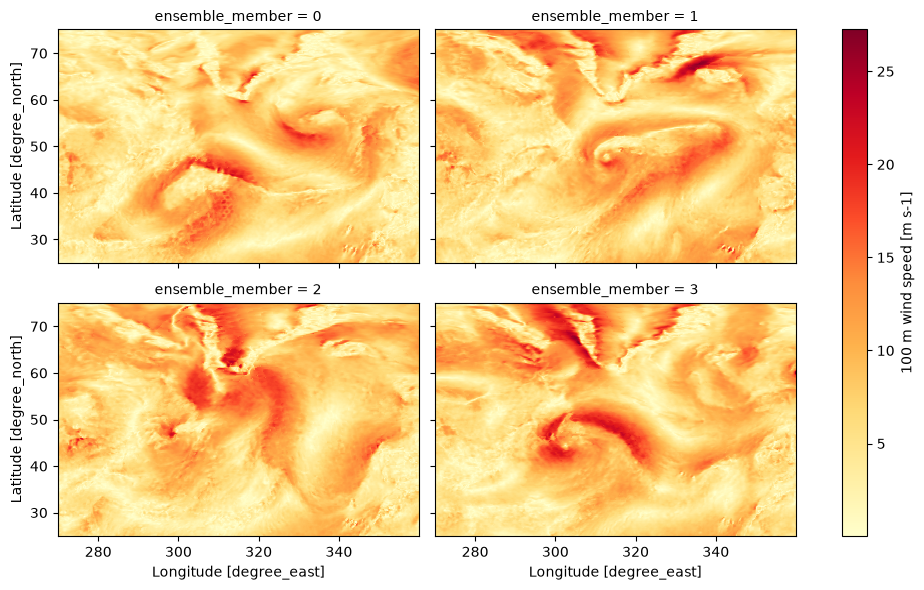

In [5]:
latest = (
    operational.isel(init_time=-1)
    .sel(
        ensemble_member=slice(0, 3),
        lead_time="240h",
        y=slice(25, 75),
        x=slice(270, 359.75),
    )
)

wind_speed_100m = (latest["wind_u_100m"] ** 2 + latest["wind_v_100m"] ** 2) ** 0.5
wind_speed_100m = wind_speed_100m.load()
wind_speed_100m.attrs["long_name"] = "100 m wind speed"
_ = wind_speed_100m.plot(
    x="x", y="y", col="ensemble_member", col_wrap=2, figsize=(10, 6), cmap="YlOrRd"
)

### Where to go next

- Use the historical product to backtest an ensemble-derived decision rule across 2022–2024, then apply the same code to the operational archive.
- At one lead, load all 64 members and calculate the probability of temperature or wind exceeding an application-specific threshold. This is a larger read: each member is a full-globe source chunk.
- Open the `pressure_level` group to examine whether wind, temperature, and geopotential-height scenarios remain physically coherent through the atmosphere.

For official forecasts and warnings, always consult the relevant national meteorological service.